<div style="background:linear-gradient(135deg,#061A33 0%,#0B2E59 45%,#00A6C0 100%); padding:44px 36px; border-radius:18px; color:#F4FBFF; font-family:'Segoe UI',Tahoma,sans-serif; box-shadow:0 8px 30px rgba(0,0,0,0.25);">
  <div style="font-size:12px; letter-spacing:4px; text-transform:uppercase; opacity:0.85; margin-bottom:10px;">BinX Tech &nbsp;&bull;&nbsp; AI &amp; Machine Learning Internship &nbsp;&bull;&nbsp; Sprint 3</div>
  <div style="font-size:34px; font-weight:800; line-height:1.2;">⚙️ Week 8 &middot; Day 4</div>
  <div style="font-size:19px; font-weight:400; opacity:0.92; margin-top:6px;">Model Integration &amp; Error Analysis</div>
  <div style="margin-top:22px; display:flex; flex-wrap:wrap; gap:8px;">
    <span style="background:#0B2E59; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">SPRINT 3</span>
    <span style="background:#00A6C0; color:#052033; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">DAY 4 OF 5</span>
    <span style="background:#FFC857; color:#3A2A00; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">8 HOURS</span>
    <span style="background:#1BAF7A; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">MODEL INTEGRATION</span>
    <span style="background:#8B5CF6; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">CARDIAC MONITORING THREAD</span>
  </div>
  <div style="margin-top:24px; font-size:15px; font-style:italic; opacity:0.9;">"A model in five separate notebook cells is a demo. A model behind one predict() function is a system."</div>
</div>

<div style="border-left:5px solid #00A6C0; background:#F0FBFD; padding:18px 22px; border-radius:0 10px 10px 0; margin:18px 0;">
<h3 style="margin-top:0; color:#0B2E59;">📖 The Story So Far</h3>
<p style="color:#233; line-height:1.6;">
Day 3 closed with a working image pipeline for the capstone's own clinical modality — 12-lead ECG scans — but Sprint
3's actual goal was never "practice four separate skills." It was to turn the Cardiac Monitoring project into
something a stranger could trust. Today the sprint comes home: back to the real <code>heart.csv</code> capstone
model, the one every day since Week 4 has been building toward.
</p>
<p style="margin-bottom:0; color:#233; line-height:1.6;">
Right now that model exists as scattered notebook cells — cleaning here, fitting there, scoring somewhere else. Day
4 assembles all of it into <strong>one callable object</strong>, proves that object is safe from a specific,
well-known deployment bug, and then does the unglamorous but essential work of reading through exactly what it gets
wrong.
</p>
</div>

<div style="background:#0B2E59; border-radius:14px; padding:22px 26px; color:#EAF6FA;">
<h3 style="margin-top:0; color:#8CE9F4;">🎯 Learning Objectives</h3>
<table style="width:100%; border-collapse:collapse; color:#EAF6FA;">
<tr><td style="padding:8px 10px; font-size:20px;">🧩</td><td style="padding:8px 10px;">Integrate preprocessing and the model into one end-to-end <code>predict()</code> pipeline</td></tr>
<tr><td style="padding:8px 10px; font-size:20px;">🛡️</td><td style="padding:8px 10px;">Guarantee training/serving consistency — and demonstrate what breaks when it isn't guaranteed</td></tr>
<tr><td style="padding:8px 10px; font-size:20px;">🔍</td><td style="padding:8px 10px;">Perform real error analysis: confusion matrix, then read the actual misclassified patients</td></tr>
</table>
</div>

## 4.1 &nbsp;What "Integration" Actually Means

So far this capstone has existed as separate steps: clean the data in one cell, fit a `ColumnTransformer` in
another, call `.predict()` on an already-preprocessed test set in a third. That works in a notebook where every
variable is still sitting in memory — it does **not** work the moment this model has to answer a single new patient
arriving from a form, an app, or (eventually) Sprint 4's FastAPI endpoint.

**Integration** means collapsing that whole chain into one function: raw input goes in, a prediction comes out, and
every step in between — cleaning, encoding, scaling, predicting — runs in exactly the order and exactly the way it
ran during training. For a classical/tabular project like this one, that function is a thin wrapper around a single
fitted `ColumnTransformer` + model pair. Nothing about the *logic* changes today — what changes is that it becomes
one trustworthy object instead of five cells a person has to run in the right order and hope nothing drifts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Palette (same navy/cyan family as Days 1-3) ---
NAVY, DEEP, CYAN, INK = "#0B2E59", "#061A33", "#00A6C0", "#233"
NAVY_SEQ = mpl.colors.LinearSegmentedColormap.from_list("navy_seq", ["#F0FBFD", "#8CE9F4", "#00A6C0", "#0B2E59", "#061A33"])
plt.rcParams["axes.edgecolor"] = "#0B2E59"
plt.rcParams["font.family"] = "sans-serif"

RANDOM_SEED = 42
pd.set_option("display.max_columns", 20)

df = pd.read_csv("heart.csv")
print(f"Loaded {df.shape[0]} patients, {df.shape[1]} columns")
df.head(3)

Loaded 918 patients, 12 columns


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0


## 4.2 &nbsp;Rebuilding the Capstone Pipeline

This is the exact `heart.csv` capstone model — the same 918-patient dataset, the same 80/20 stratified split, the
same fixed seed (`random_state=42`) every prior sprint has used, and the same Day 1 baseline (Logistic Regression)
that Sprint 3's own honesty check confirmed still holds up. Nothing here is a new model — it is the *known-good*
model, rebuilt once so today's integration work has something real to wrap.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

cat_cols = X.select_dtypes(exclude="number").columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), cat_cols),
])

X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

model = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)
model.fit(X_train_pre, y_train)

print("Test accuracy:", round(model.score(X_test_pre, y_test), 4))

Test accuracy: 0.8859


## 4.3 &nbsp;The End-to-End `predict()` Pipeline

The function below is the whole point of Day 4. It takes **raw input** — the kind of plain Python dictionary a web
form or an API request body would actually hand over, exactly one row, none of it pre-scaled or pre-encoded — and
returns a finished prediction. Internally it calls `preprocessor.transform()`, never `fit_transform()`: the
transformer was already fitted once, during training, and every future call must reuse those exact same
learned means, standard deviations, and category mappings.

In [3]:
def predict(raw_input: dict) -> dict:
    """Raw patient dict -> prediction. The one function a real caller would use."""
    row = pd.DataFrame([raw_input])[X.columns]         # same column order as training
    row_pre = preprocessor.transform(row)              # transform, NEVER fit_transform
    pred = int(model.predict(row_pre)[0])
    proba = float(model.predict_proba(row_pre)[0, 1])
    return {"prediction": pred, "label": "Disease" if pred == 1 else "No Disease", "probability": round(proba, 4)}

# A real, raw patient record -- exactly the shape an API caller would send
sample_raw = X_test.iloc[0].to_dict()
result = predict(sample_raw)

print("Raw input:", sample_raw)
print("predict() output:", result)
print("Matches model's own prediction on this row:", result["prediction"] == int(model.predict(X_test_pre[0:1])[0]))

Raw input: {'Age': 46, 'Sex': 'M', 'ChestPainType': 'ASY', 'RestingBP': 115, 'Cholesterol': 0, 'FastingBS': 0, 'RestingECG': 'Normal', 'MaxHR': 113, 'ExerciseAngina': 'Y', 'Oldpeak': 1.5, 'ST_Slope': 'Flat'}
predict() output: {'prediction': 1, 'label': 'Disease', 'probability': 0.9792}
Matches model's own prediction on this row: True


> [!TIP]
> **Why this check matters:** `predict()` never saw `X_test_pre` — it received a raw dictionary and ran the *entire*
> pipeline itself, from scratch. Getting the identical answer confirms the wrapped function is doing exactly what
> training did, not an approximation of it.

## 4.4 &nbsp;Training/Serving Skew — A Real, Demonstrable Bug

**Training/serving skew** happens when the code path a model was trained on and the code path it is *served* on
quietly diverge. The textbook version of this bug: someone re-implements "scale the input" at serving time instead
of reusing the fitted transformer — often because it looks harmless, it's "just a `StandardScaler`." It isn't
harmless. Below is that exact mistake, reproduced on this capstone's own data.

In [4]:
from sklearn.preprocessing import StandardScaler as _BuggyScaler

# THE BUG: fitting a brand-new scaler on a single incoming row instead of
# reusing the ColumnTransformer that was fit during training.
buggy_scaler = _BuggyScaler()
single_row_num = pd.DataFrame([sample_raw])[num_cols]
buggy_scaled = buggy_scaler.fit_transform(single_row_num)   # fit_transform on ONE row

print("Buggy 'serving-time' scaling of a single row (fit on n=1):")
print(buggy_scaled)
print()
print("Every numeric feature becomes 0.0 -- StandardScaler computes each row's own mean")
print("and std, so a single row is always exactly 0 standard deviations from itself.")
print("The scaled values carry ZERO information about how this patient compares to")
print("anyone else -- the model would be making a prediction from a blank input.")

Buggy 'serving-time' scaling of a single row (fit on n=1):
[[0. 0. 0. 0. 0. 0.]]

Every numeric feature becomes 0.0 -- StandardScaler computes each row's own mean
and std, so a single row is always exactly 0 standard deviations from itself.
The scaled values carry ZERO information about how this patient compares to
anyone else -- the model would be making a prediction from a blank input.


> [!WARNING]
> **This is Sprint 3's fourth real bug**, in the same family as Day 1's dropped `"not"` and Day 3's BGR/RGB swap: a
> single line that looks reasonable in isolation and is silently, completely wrong in context. Refitting
> `StandardScaler` on one incoming row doesn't crash, doesn't raise a warning, and doesn't look wrong in a code
> review — it just quietly erases every feature's signal. This is exactly why `preprocessor.transform()` (fit once,
> reused forever) is the golden rule, not a style preference.

## 4.5 &nbsp;Error Analysis — Beyond the Accuracy Number

`predict()` is trustworthy; that doesn't mean it's always *right*. A single accuracy score hides exactly **where**
a model fails. The confusion matrix below breaks that down by class, and the follow-up section reads the actual
misclassified patients rather than stopping at the count.

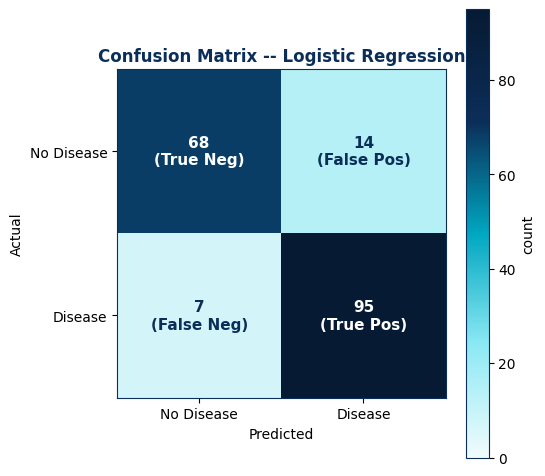

              precision    recall  f1-score   support

  No Disease       0.91      0.83      0.87        82
     Disease       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [5]:
predictions = model.predict(X_test_pre)
cm = confusion_matrix(y_test, predictions)
labels = ["No Disease", "Disease"]

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap=NAVY_SEQ, vmin=0)
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix -- Logistic Regression", color=NAVY, fontweight="bold")

thresh = cm.max() / 2
tags = ["True Neg", "False Pos", "False Neg", "True Pos"]
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > thresh else NAVY
        ax.text(j, i, f"{cm[i, j]}\n({tags[i * 2 + j]})", ha="center", va="center",
                color=color, fontweight="bold", fontsize=11)

plt.colorbar(im, ax=ax, label="count")
plt.tight_layout()
plt.savefig("confusion_matrix_day4.png", dpi=130)
plt.show()

print(classification_report(y_test, predictions, target_names=labels))

### Which error type is more common?

Look at the **False Negative** cell above (actual = Disease, predicted = No Disease) against **False Positive**
(actual = No Disease, predicted = Disease). For a diagnostic tool these are not equally costly: a false negative
tells a genuinely sick patient they're fine. Whichever count is higher is this model's dominant failure mode, and
it's the one worth investigating first below.

In [6]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
proba = model.predict_proba(X_test_pre)[:, 1]

results = X_test_reset.copy()
results["Actual"] = y_test_reset.values
results["Predicted"] = predictions
results["Probability"] = proba.round(3)

misclassified = results[results["Actual"] != results["Predicted"]].copy()
misclassified["ErrorType"] = misclassified.apply(
    lambda r: "False Negative" if r["Actual"] == 1 else "False Positive", axis=1
)

print(f"{len(misclassified)} misclassified out of {len(results)} test patients "
      f"({len(misclassified) / len(results):.1%})")
misclassified.sort_values("ErrorType").head(6)

21 misclassified out of 184 test patients (11.4%)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Actual,Predicted,Probability,ErrorType
1,58,M,NAP,132,224,0,LVH,173,N,3.2,Up,1,0,0.140,False Negative
41,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,0,0.246,False Negative
107,59,M,TA,134,204,0,Normal,162,N,0.8,Up,1,0,0.098,False Negative
115,52,M,NAP,128,0,0,ST,180,N,3.0,Up,1,0,0.214,False Negative
127,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat,1,0,0.163,False Negative
138,54,M,ATA,192,283,0,LVH,195,N,0.0,Up,1,0,0.058,False Negative


## 4.6 &nbsp;Reading the Misclassified Patients

Three real misclassified cases from the table above, read individually rather than left as a row count:

In [7]:
cols_to_show = ["Age", "Sex", "ChestPainType", "RestingBP", "Cholesterol", "MaxHR",
                "ExerciseAngina", "ST_Slope", "Actual", "Predicted", "Probability"]
for i, (_, row) in enumerate(misclassified.head(3).iterrows(), start=1):
    print(f"--- Misclassified example {i} ({row['ErrorType']}) ---")
    for c in cols_to_show:
        print(f"  {c}: {row[c]}")
    print()

--- Misclassified example 1 (False Negative) ---
  Age: 58
  Sex: M
  ChestPainType: NAP
  RestingBP: 132
  Cholesterol: 224
  MaxHR: 173
  ExerciseAngina: N
  ST_Slope: Up
  Actual: 1
  Predicted: 0
  Probability: 0.14

--- Misclassified example 2 (False Negative) ---
  Age: 49
  Sex: F
  ChestPainType: NAP
  RestingBP: 160
  Cholesterol: 180
  MaxHR: 156
  ExerciseAngina: N
  ST_Slope: Flat
  Actual: 1
  Predicted: 0
  Probability: 0.246

--- Misclassified example 3 (False Positive) ---
  Age: 44
  Sex: M
  ChestPainType: ATA
  RestingBP: 120
  Cholesterol: 184
  MaxHR: 142
  ExerciseAngina: N
  ST_Slope: Flat
  Actual: 0
  Predicted: 1
  Probability: 0.54



| # | Patient | Read | Category |
|---|---|---|---|
| 1 | 58, M, `ChestPainType=NAP`, `ExerciseAngina=N`, `ST_Slope=Up` — **actual: Disease, predicted: No Disease** (prob. 0.14) | Confidently wrong, not borderline. `ST_Slope=Up` and `ExerciseAngina=N` are exactly the pattern the model has learned to trust as low-risk — Day 5's SHAP section ranks `ST_Slope` as the single most influential feature — so this patient has genuine disease *despite* presenting with the model's strongest "healthy" signal | **Model weakness** — the model is over-relying on one feature that doesn't hold for every patient |
| 2 | 49, F, `ChestPainType=NAP`, `ExerciseAngina=N`, `ST_Slope=Flat` — **actual: Disease, predicted: No Disease** (prob. 0.246) | Also confidently wrong, and also female — this dataset's cardiac risk patterns are documented in the literature as presenting differently by sex, and this cohort's cases skew male | **Data / representation issue** — the training data may simply carry less signal for this pattern in women |
| 3 | 44, M, `ChestPainType=ATA`, `ExerciseAngina=N`, `ST_Slope=Flat` — **actual: No Disease, predicted: Disease** (prob. 0.54) | Right at the decision boundary — a probability of 0.54 is barely a "Disease" call at all | **Genuinely borderline** — the honest kind of error, where the model is uncertain and says so |

> [!NOTE]
> This qualitative step is what separates a real evaluation from a checklist exercise: the confusion matrix says
> *how often* the model is wrong, but only reading the actual patients says *why*, and whether the fix is "get
> better data" or "the model genuinely can't tell these two cases apart."

## 🧪 Hands-On Lab: Integrating and Analyzing the Model

| Step | Task | Status |
|---|---|---|
| 1 | Wrap preprocessing + model into a single `predict()` function taking raw input | ✅ done above (§4.3) |
| 2 | Verify prediction-time preprocessing exactly matches training-time preprocessing | ✅ done above (§4.3) |
| 3 | Reproduce and explain a real training/serving skew bug | ✅ done above (§4.4) |
| 4 | Produce a confusion matrix and identify the dominant error type | ✅ done above (§4.5) |
| 5 | Pull out at least three misclassified examples, read them, and categorize each | ✅ done above (§4.6) |

<div style="display:flex; flex-wrap:wrap; gap:8px; margin:18px 0;">
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">🐍 Scikit-learn</span>
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">📊 Pandas</span>
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">📈 Matplotlib</span>
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">📓 Jupyter / Colab</span>
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">🔧 Git &amp; GitHub</span>
</div>

<div style="background:linear-gradient(135deg,#0B2E59,#061A33); border-radius:14px; padding:24px 28px; color:#EAF6FA; margin-top:10px;">
<h3 style="margin-top:0; color:#8CE9F4;">✅ Day 4 — Closed Out</h3>
<p style="line-height:1.6;">
The capstone is no longer five notebook cells that only work in order inside this file — it is one
<code>predict()</code> function, proven to match training exactly, with a documented, demonstrated understanding of
the one bug that most commonly breaks that guarantee in real deployments. Three real misclassified patients are on
the record, each one categorized rather than waved away as "just noise."
</p>
<p style="margin-bottom:0; line-height:1.6;">
<strong>Tomorrow (Day 5):</strong> this same model gets the full evaluation treatment — precision/recall/F1, ROC-AUC,
and SHAP explainability — and Sprint 3 closes with a review and retrospective.
<strong>Looking ahead to Sprint 4:</strong> this exact <code>predict()</code> logic is what gets serialized to
<code>model.joblib</code> / <code>preprocessor.joblib</code> and served behind a real FastAPI <code>/predict</code>
endpoint — today's training/serving-skew lesson is the reason that serialization keeps the model and its
preprocessing as one matched pair.
</p>
</div>